# CSC 301: Algorithm Analysis and Design Project

# Decision Tree Algorithm

## Algorithm Type
**Greedy / Recursive**

## Problem Context
In this project, the Decision Tree algorithm is used to solve the Heart Disease Prediction problem, which is formulated as a classification problem.  
Given a dataset of patients described by several medical attributes, the goal is to determine whether a patient belongs to one of two classes: having heart disease or not having heart disease.

**Decision Tree** was chosen because it represents a clear greedy algorithmic approach that recursively splits data based on the best feature at each step. It is suitable for performance analysis in terms of time complexity, space complexity, and scalability with input size.

In [35]:
# Import libraries
import pandas as pd # for data loading and analysis

import matplotlib.pyplot as plt # for plotting graphs

from sklearn.model_selection import train_test_split # function to split data into training and testing sets

from sklearn.tree import DecisionTreeClassifier # import Decision Tree algorithm

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay # functions to evaluate model performance

import time # For measuring time

import numpy as np # For Numerical Calculations

In [36]:
# Load the dataset into a pandas DataFrame
df = pd.read_csv("synthetic_heart_disease_dataset.csv")

# Display first 5 rows
df.head()

,Age,Gender,Weight,Height,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,...,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
0,48,Male,78,157,26.4,Never,NaN,Sedentary,Healthy,Medium,...,0,1,1,0,104,99,71,165,200,0
1,35,Female,73,163,33.0,Never,Low,Active,Average,High,...,0,1,1,0,111,72,60,145,206,0
2,79,Female,88,152,32.3,Never,NaN,Moderate,Average,Medium,...,0,0,1,0,116,102,78,148,208,0
3,75,Male,106,171,37.4,Never,Moderate,Moderate,Average,Low,...,0,1,0,0,171,92,109,105,290,1
4,34,Female,65,191,18.5,Current,NaN,Sedentary,Healthy,Low,...,1,0,0,0,164,67,108,116,220,1


In [37]:
# Display basic information about the dataset
# This shows column names, data types, and number of non-null entries
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 21 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Age                    50000 non-null  int64  
 1   Gender                 50000 non-null  object 
 2   Weight                 50000 non-null  int64  
 3   Height                 50000 non-null  int64  
 4   BMI                    50000 non-null  float64
 5   Smoking                50000 non-null  object 
 6   Alcohol_Intake         29891 non-null  object 
 7   Physical_Activity      50000 non-null  object 
 8   Diet                   50000 non-null  object 
 9   Stress_Level           50000 non-null  object 
 10  Hypertension           50000 non-null  int64  
 11  Diabetes               50000 non-null  int64  
 12  Hyperlipidemia         50000 non-null  int64  
 13  Family_History         50000 non-null  int64  
 14  Previous_Heart_Attack  50000 non-null  int64  
 15  Sy

In [38]:
# Check the shape of the dataset (rows, columns)
# This tells us the total number of patient records and features
print("Dataset shape:", df.shape)

# Display summary statistics for numerical columns
# This includes mean, std, min, max, and quartiles
df.describe()

Dataset shape: (50000, 21)


,Age,Weight,Height,BMI,Hypertension,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
count,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,54.46406,84.547520,174.460000,28.984284,0.299620,0.199260,0.251660,0.400500,0.099280,139.299580,89.528800,84.449560,124.493020,224.556360,0.463460
std,14.43809,20.213257,14.420379,6.367494,0.458096,0.399448,0.433971,0.490005,0.299041,23.083544,17.258063,14.491325,31.691507,43.157467,0.498668
min,30.00000,50.000000,150.000000,18.000000,0.000000,0.000000,0.000000,0.000000,0.000000,100.000000,60.000000,60.000000,70.000000,150.000000,0.000000
25%,42.00000,67.000000,162.000000,23.500000,0.000000,0.000000,0.000000,0.000000,0.000000,119.000000,75.000000,72.000000,97.000000,187.000000,0.000000
50%,54.00000,85.000000,174.000000,29.000000,0.000000,0.000000,0.000000,0.000000,0.000000,139.000000,90.000000,85.000000,125.000000,225.000000,0.000000
75%,67.00000,102.000000,187.000000,34.500000,1.000000,0.000000,1.000000,1.000000,0.000000,159.000000,104.000000,97.000000,152.000000,262.000000,1.000000
max,79.00000,119.000000,199.000000,40.000000,1.000000,1.000000,1.000000,1.000000,1.000000,179.000000,119.000000,109.000000,179.000000,299.000000,1.000000


In [39]:
# Check for missing values in the dataset
# Decision Tree can handle some missing data, but it's good to verify
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
Age                          0
Gender                       0
Weight                       0
Height                       0
BMI                          0
Smoking                      0
Alcohol_Intake           20109
Physical_Activity            0
Diet                         0
Stress_Level                 0
Hypertension                 0
Diabetes                     0
Hyperlipidemia               0
Family_History               0
Previous_Heart_Attack        0
Systolic_BP                  0
Diastolic_BP                 0
Heart_Rate                   0
Blood_Sugar_Fasting          0
Cholesterol_Total            0
Heart_Disease                0
dtype: int64


In [40]:
# Check for duplicate records
df.duplicated().sum()

np.int64(0)

In [41]:
# Fill missing values with the most frequent value
df["Alcohol_Intake"] = df["Alcohol_Intake"].fillna(df["Alcohol_Intake"].mode()[0])

In [42]:
# Verify that no missing records remain after removing missing values
df.isnull().sum()

Age                      0
Gender                   0
Weight                   0
Height                   0
BMI                      0
Smoking                  0
Alcohol_Intake           0
Physical_Activity        0
Diet                     0
Stress_Level             0
Hypertension             0
Diabetes                 0
Hyperlipidemia           0
Family_History           0
Previous_Heart_Attack    0
Systolic_BP              0
Diastolic_BP             0
Heart_Rate               0
Blood_Sugar_Fasting      0
Cholesterol_Total        0
Heart_Disease            0
dtype: int64

In [43]:
# Check class distribution in the target variable
# This shows how many patients have heart disease (1) vs. don't have (0)
print("Class distribution:")
print(df['Heart_Disease'].value_counts())

Class distribution:
Heart_Disease
0    26827
1    23173
Name: count, dtype: int64


In [44]:
# Encode categorical variables to numerical values
# Create a copy of the dataframe to avoid modifying the original
df_encoded = df.copy()

# List of categorical columns that need to be converted to numbers
categorical_cols = ['Gender', 'Smoking', 'Alcohol_Intake', 'Physical_Activity',
                   'Diet', 'Stress_Level', 'Diabetes', 'Hyperlipidemia',
                   'Family_History', 'Previous_Heart_Attack']

# Convert each categorical column to numerical codes (0, 1, 2, etc.)
for col in categorical_cols:
    df_encoded[col] = df_encoded[col].astype('category').cat.codes

# Verify encoding worked by displaying first few rows
df_encoded.head()

,Age,Gender,Weight,Height,BMI,Smoking,Alcohol_Intake,Physical_Activity,Diet,Stress_Level,...,Diabetes,Hyperlipidemia,Family_History,Previous_Heart_Attack,Systolic_BP,Diastolic_BP,Heart_Rate,Blood_Sugar_Fasting,Cholesterol_Total,Heart_Disease
0,48,1,78,157,26.4,2,1,2,1,2,...,0,1,1,0,104,99,71,165,200,0
1,35,0,73,163,33.0,2,1,0,0,0,...,0,1,1,0,111,72,60,145,206,0
2,79,0,88,152,32.3,2,1,1,0,2,...,0,0,1,0,116,102,78,148,208,0
3,75,1,106,171,37.4,2,2,1,0,1,...,0,1,0,0,171,92,109,105,290,1
4,34,0,65,191,18.5,0,1,2,1,1,...,1,0,0,0,164,67,108,116,220,1


In [54]:
# Store input sizes
small_sizes = [100, 500, 1000, 2000]
small_results = {}
small_all_times = {}

# Loop over the specified sizes
for size in small_sizes:
    times = []
    print(f"\n** Input size = {size} **")
    
    df_sample = df_encoded.sample(n=size, random_state=42)
    X = df_sample.drop(["Heart_Disease", "Previous_Heart_Attack", "Alcohol_Intake"], axis=1)
    y = df_sample["Heart_Disease"]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Do the experiment 20 times
    for i in range(1, 21):
        dt_classifier = DecisionTreeClassifier(
            criterion='gini',
            max_depth=20,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=42
        )

        start_time = time.perf_counter()
        dt_classifier.fit(X_train, y_train)
        y_pred = dt_classifier.predict(X_test)
        end_time = time.perf_counter()

        running_time = (end_time - start_time) * 1000
        times.append(running_time)

        print(f"Run {i}: {running_time:.3f} ms")

    best = min(times)
    worst = max(times)
    avg = sum(times) / len(times)

    small_results[size] = (best, avg, worst)
    small_all_times[size] = times

    print("\n--- Running cases ---")
    print(f"Best case: {best:.3f} ms")
    print(f"Average case: {avg:.3f} ms")
    print(f"Worst case: {worst:.3f} ms")


** Input size = 100 **
Run 1: 9.083 ms
Run 2: 9.662 ms
Run 3: 9.711 ms
Run 4: 10.955 ms
Run 5: 9.225 ms
Run 6: 10.356 ms
Run 7: 12.707 ms
Run 8: 9.798 ms
Run 9: 8.180 ms
Run 10: 9.385 ms
Run 11: 19.821 ms
Run 12: 12.306 ms
Run 13: 8.835 ms
Run 14: 11.355 ms
Run 15: 11.558 ms
Run 16: 10.466 ms
Run 17: 8.572 ms
Run 18: 10.128 ms
Run 19: 13.423 ms
Run 20: 12.152 ms

--- Running cases ---
Best case: 8.180 ms
Average case: 10.884 ms
Worst case: 19.821 ms

** Input size = 500 **
Run 1: 12.717 ms
Run 2: 11.016 ms
Run 3: 13.323 ms
Run 4: 12.884 ms
Run 5: 11.883 ms
Run 6: 14.432 ms
Run 7: 12.826 ms
Run 8: 14.735 ms
Run 9: 14.548 ms
Run 10: 12.701 ms
Run 11: 11.327 ms
Run 12: 11.902 ms
Run 13: 13.045 ms
Run 14: 10.591 ms
Run 15: 10.736 ms
Run 16: 11.416 ms
Run 17: 14.871 ms
Run 18: 18.208 ms
Run 19: 13.889 ms
Run 20: 9.461 ms

--- Running cases ---
Best case: 9.461 ms
Average case: 12.826 ms
Worst case: 18.208 ms

** Input size = 1000 **
Run 1: 16.356 ms
Run 2: 22.165 ms
Run 3: 19.009 ms
Run 4:

In [55]:
# Store input sizes
large_sizes = [10000, 20000, 30000, 40000]
large_results = {}
large_all_times = {}

# Loop over the specified sizes
for size in large_sizes:
    times = []
    print(f"\n** Input size = {size} **")
    
    df_sample = df_encoded.sample(n=size, random_state=42)
    X = df_sample.drop(["Heart_Disease", "Previous_Heart_Attack", "Alcohol_Intake"], axis=1)
    y = df_sample["Heart_Disease"]
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    # Do the experiment 20 times
    for i in range(1, 21):
        dt_classifier = DecisionTreeClassifier(
            criterion='gini',
            max_depth=20,
            min_samples_split=10,
            min_samples_leaf=5,
            random_state=42
        )

        start_time = time.perf_counter()
        dt_classifier.fit(X_train, y_train)
        y_pred = dt_classifier.predict(X_test)
        end_time = time.perf_counter()

        running_time = (end_time - start_time) * 1000
        times.append(running_time)

        print(f"Run {i}: {running_time:.3f} ms")

    best = min(times)
    worst = max(times)
    avg = sum(times) / len(times)

    large_results[size] = (best, avg, worst)
    large_all_times[size] = times

    print("\n--- Running cases ---")
    print(f"Best case: {best:.3f} ms")
    print(f"Average case: {avg:.3f} ms")
    print(f"Worst case: {worst:.3f} ms")


** Input size = 10000 **
Run 1: 90.573 ms
Run 2: 93.877 ms
Run 3: 99.642 ms
Run 4: 85.545 ms
Run 5: 85.936 ms
Run 6: 87.461 ms
Run 7: 78.933 ms
Run 8: 83.113 ms
Run 9: 79.592 ms
Run 10: 82.902 ms
Run 11: 92.566 ms
Run 12: 80.557 ms
Run 13: 89.072 ms
Run 14: 89.804 ms
Run 15: 86.670 ms
Run 16: 86.702 ms
Run 17: 81.545 ms
Run 18: 83.037 ms
Run 19: 85.664 ms
Run 20: 100.639 ms

--- Running cases ---
Best case: 78.933 ms
Average case: 87.192 ms
Worst case: 100.639 ms

** Input size = 20000 **
Run 1: 216.782 ms
Run 2: 167.649 ms
Run 3: 154.128 ms
Run 4: 141.366 ms
Run 5: 167.502 ms
Run 6: 162.685 ms
Run 7: 170.692 ms
Run 8: 170.605 ms
Run 9: 145.275 ms
Run 10: 161.137 ms
Run 11: 158.528 ms
Run 12: 156.940 ms
Run 13: 195.531 ms
Run 14: 219.485 ms
Run 15: 165.787 ms
Run 16: 154.864 ms
Run 17: 167.276 ms
Run 18: 181.306 ms
Run 19: 169.630 ms
Run 20: 171.536 ms

--- Running cases ---
Best case: 141.366 ms
Average case: 169.935 ms
Worst case: 219.485 ms

** Input size = 30000 **
Run 1: 295.152 

In [56]:
# Define function which generates a table of run times
def create_main_table(all_times_dict):
    table_data = {}

    for size, times in all_times_dict.items():
        table_data[size] = times

    df_table = pd.DataFrame(table_data, index=[f"Time {i} (ms)" for i in range(1, 21)])

    experimental_avg = [sum(all_times_dict[size]) / len(all_times_dict[size]) for size in all_times_dict.keys()]
    df_table.loc["Experimental Average"] = experimental_avg

    theoretical = [size * np.log2(size) for size in all_times_dict.keys()]
    scale_factor = experimental_avg[-1] / theoretical[-1]
    theoretical_scaled = [x * scale_factor for x in theoretical]
    df_table.loc["Theoretical Estimate"] = theoretical_scaled

    ratio = [experimental_avg[i] / theoretical_scaled[i] for i in range(len(experimental_avg))]
    df_table.loc["Experimental/Theory"] = ratio

    return df_table.round(4)

In [57]:
# Generate table for small inputs
small_main_table = create_main_table(small_all_times)

print("SMALL INPUTS - MAIN TABLE")
display(small_main_table)

SMALL INPUTS - MAIN TABLE


,100,500,1000,2000
Time 1 (ms),9.0828,12.7165,16.3556,23.0812
Time 2 (ms),9.6623,11.0157,22.1653,26.0233
Time 3 (ms),9.7108,13.3230,19.0089,25.3209
Time 4 (ms),10.9554,12.8843,20.5152,37.1411
Time 5 (ms),9.2248,11.8830,19.6260,27.1831
Time 6 (ms),10.3562,14.4324,20.8012,25.7363
Time 7 (ms),12.7070,12.8259,17.5432,27.9981
Time 8 (ms),9.7979,14.7349,20.7447,46.3995
Time 9 (ms),8.1804,14.5480,21.3594,29.5900
Time 10 (ms),9.3851,12.7007,17.9772,35.4488


In [58]:
# Generate table for large inputs
large_main_table = create_main_table(large_all_times)

print("LARGE INPUTS - MAIN TABLE")
display(large_main_table)

LARGE INPUTS - MAIN TABLE


,10000,20000,30000,40000
Time 1 (ms),90.5733,216.7818,295.1518,340.2825
Time 2 (ms),93.8774,167.6492,300.3258,389.8048
Time 3 (ms),99.6424,154.1282,272.9246,343.9192
Time 4 (ms),85.5452,141.3656,297.8566,345.4851
Time 5 (ms),85.9357,167.5023,302.8428,381.0932
Time 6 (ms),87.4611,162.6849,284.4493,425.9315
Time 7 (ms),78.9330,170.6922,296.2512,365.0344
Time 8 (ms),83.1128,170.6046,264.2336,354.6806
Time 9 (ms),79.5916,145.2745,262.4810,353.2652
Time 10 (ms),82.9023,161.1369,269.2438,455.4966


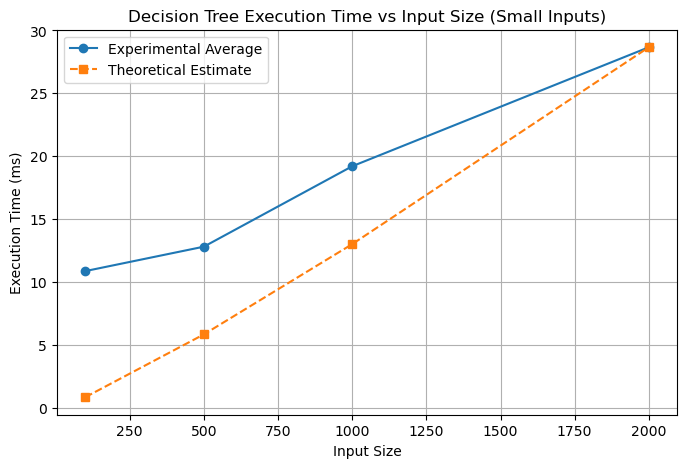

In [59]:
# Plot for the values in the run machine (small inputs)
small_avg_times = [small_results[size][1] for size in small_sizes]
small_theoretical = [size * np.log2(size) for size in small_sizes]

scale_factor_small = small_avg_times[-1] / small_theoretical[-1]
small_theoretical_scaled = [x * scale_factor_small for x in small_theoretical]

plt.figure(figsize=(8, 5))
plt.plot(small_sizes, small_avg_times, marker='o', label='Experimental Average')
plt.plot(small_sizes, small_theoretical_scaled, marker='s', linestyle='--', label='Theoretical Estimate')
plt.title("Decision Tree Execution Time vs Input Size (Small Inputs)")
plt.xlabel("Input Size")
plt.ylabel("Execution Time (ms)")
plt.grid(True)
plt.legend()
plt.show()

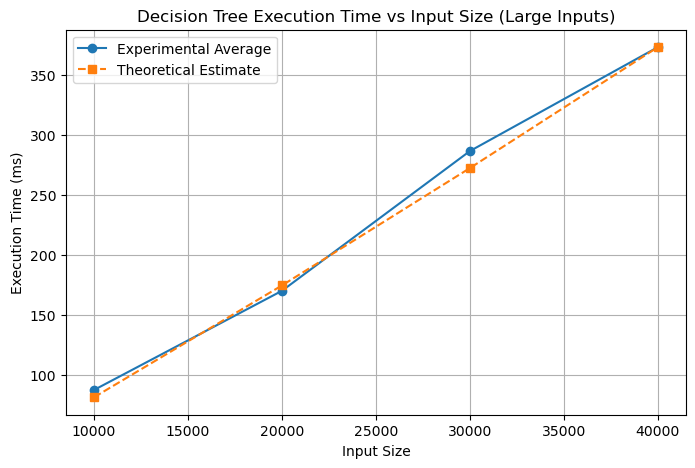

In [60]:
# Plot for the values in the run machine (large inputs)
large_avg_times = [large_results[size][1] for size in large_sizes]
large_theoretical = [size * np.log2(size) for size in large_sizes]

scale_factor_large = large_avg_times[-1] / large_theoretical[-1]
large_theoretical_scaled = [x * scale_factor_large for x in large_theoretical]

plt.figure(figsize=(8, 5))
plt.plot(large_sizes, large_avg_times, marker='o', label='Experimental Average')
plt.plot(large_sizes, large_theoretical_scaled, marker='s', linestyle='--', label='Theoretical Estimate')
plt.title("Decision Tree Execution Time vs Input Size (Large Inputs)")
plt.xlabel("Input Size")
plt.ylabel("Execution Time (ms)")
plt.grid(True)
plt.legend()
plt.show()

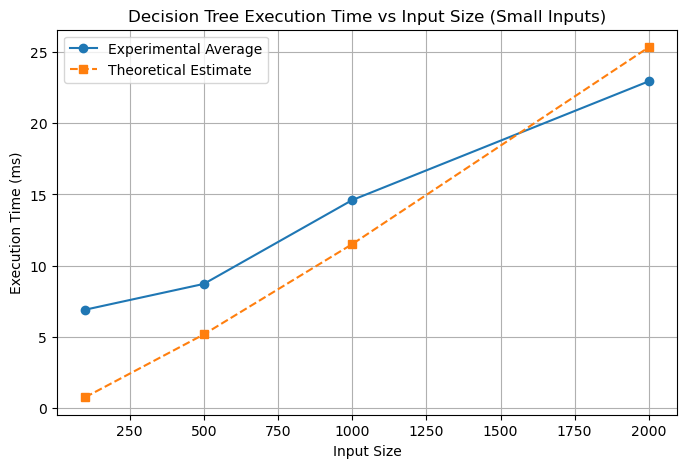

In [61]:
# Plot for the values reported in the submission (small inputs)

# Small input sizes
small_sizes = [100, 500, 1000, 2000]

#Experimental and Theoretical values in the report
small_avg_times = [6.9095, 8.7209, 14.6032, 22.9414]
small_theoretical = [0.7673, 5.1776, 11.5101, 25.3302]

# Plot the graph
plt.figure(figsize=(8, 5))
plt.plot(small_sizes, small_avg_times, marker='o', label='Experimental Average')
plt.plot(small_sizes, small_theoretical, marker='s', linestyle='--', label='Theoretical Estimate')

plt.title("Decision Tree Execution Time vs Input Size (Small Inputs)")
plt.xlabel("Input Size")
plt.ylabel("Execution Time (ms)")
plt.grid(True)
plt.legend()

plt.show()

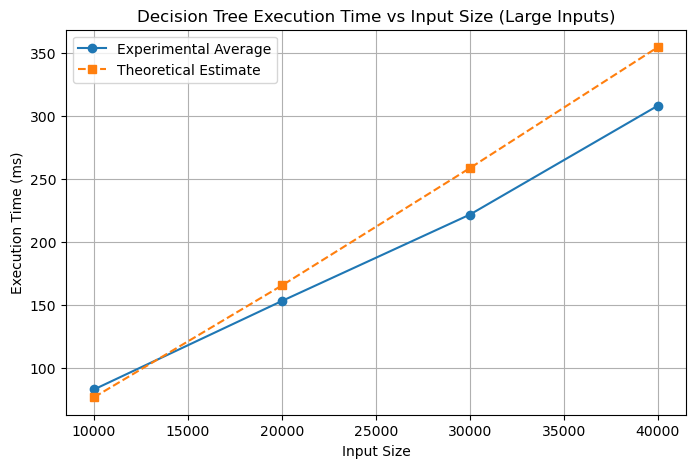

In [62]:
# Plot for the values reported in the submission (large inputs)

# Large input sizes
large_sizes = [10000, 20000, 30000, 40000]

# Experimental and Theoretical values in the report
large_avg_times = [83.2586, 153.4224, 221.9173, 308.2451]
large_theoretical = [77.0680, 165.7359, 258.7821, 354.6716]

# Plot the graph
plt.figure(figsize=(8, 5))
plt.plot(large_sizes, large_avg_times, marker='o', label='Experimental Average')
plt.plot(large_sizes, large_theoretical, marker='s', linestyle='--', label='Theoretical Estimate')

plt.title("Decision Tree Execution Time vs Input Size (Large Inputs)")
plt.xlabel("Input Size")
plt.ylabel("Execution Time (ms)")
plt.grid(True)
plt.legend()

plt.show()